In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [65]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


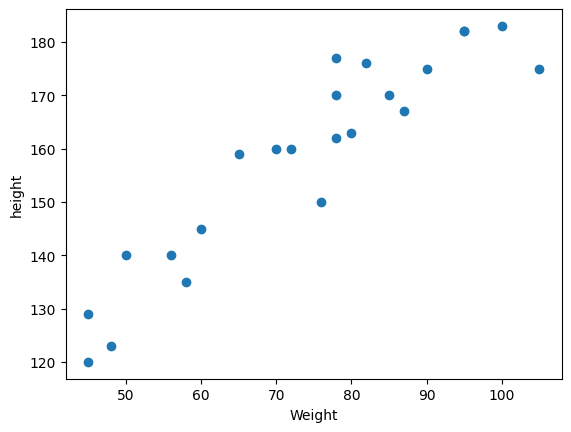

In [66]:
p=plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('height')
plt.show()

In [67]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [68]:
import seaborn as sns


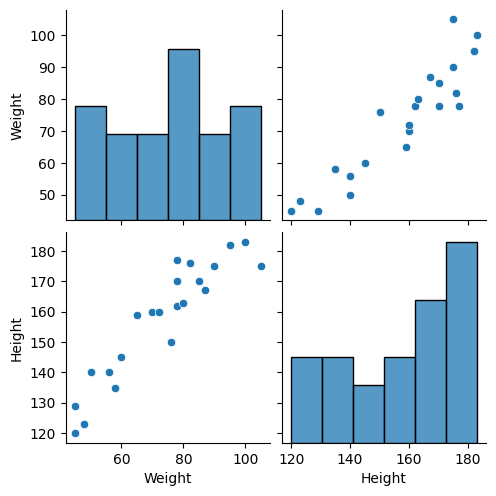

In [69]:
sns.pairplot(df)



In [70]:
#Independent and dependent features
X=df[['Weight']] #independent feature should be dataframe or 2 dimensional array
X.head()


,Weight
0,45
1,58
2,48
3,60
4,70


In [71]:
np.array(X).shape

(23, 1)

In [72]:
Y=df['Height'] #dependent features can be series
Y 

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [73]:
#Train and test split
from sklearn.model_selection import train_test_split

In [74]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [75]:
X_train.shape

(17, 1)

In [76]:
Y_train.shape

(17,)

In [77]:
#for standardization and normalization we use
from sklearn.preprocessing import StandardScaler

In [78]:
ss=StandardScaler()

In [79]:
X_train=ss.fit_transform(X_train)

In [80]:
X_test=ss.transform(X_test)
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [81]:
## now using machine learing
from sklearn.linear_model import LinearRegression

In [82]:
regression=LinearRegression(n_jobs=-1)

In [83]:
regression.fit(X_train,Y_train)

LinearRegression(n_jobs=-1)

In [84]:
print(regression.coef_)

[17.2982057]


In [85]:
print(regression.intercept_)

156.47058823529412


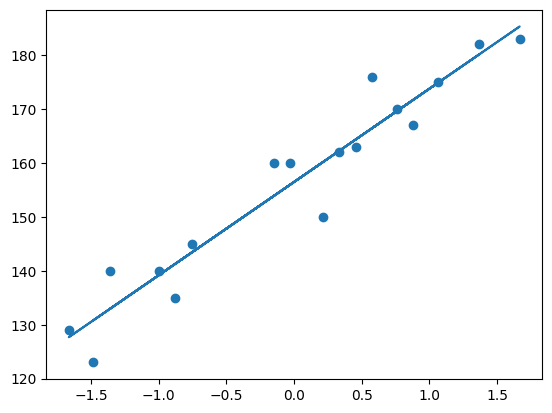

In [90]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))

In [94]:
regression.predict(ss.transform([[47.0]]))

c:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([129.77932138])

In [97]:
y_predict=regression.predict(X_test)
y_predict

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [98]:
#performance metrices
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [99]:
print(mean_squared_error(Y_test,y_predict))
print(mean_absolute_error(Y_test,y_predict))
print(np.sqrt(mean_squared_error(Y_test,y_predict)))

114.84069295228699
9.665125886795005
10.716374991212605


In [100]:
#using OLS linear regression
import statsmodels.api as sm
model=sm.OLS(Y_train,X_train).fit()

In [101]:
model.predict(X_test)

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [102]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 27 Nov 2025   Prob (F-statistic):                       0.664
Time:                        16:10:26   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\KIIT0001\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)
